In [1]:
%matplotlib inline
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [14]:
# Physics Engine and State Models
class SchwarzschildSpacetime:
    def __init__(self, M):
        self.M = M

    def null_geodesic(self, lmbda, y, b):
        t, r, phi, pr = y
        # Stop advancing if inside the horizon
        if r <= 2.001 * self.M:
            return [0, 0, 0, 0]
            
        dt_dl = 1.0 / (1.0 - 2.0 * self.M / r)
        dr_dl = pr
        dphi_dl = b / (r**2)
        dpr_dl = (b**2 / r**3) - (3.0 * self.M * b**2 / r**4)
        
        return [dt_dl, dr_dl, dphi_dl, dpr_dl]

    def trace_ray(self, source, b, direction='inward', lmbda_max=50, points=10000):
        try:
            y0 = source.get_initial_conditions(self.M, b, direction)
        except ValueError:
            return None # Skip physically impossible impact parameters
            
        def hit_horizon(lmbda, y, b_arg):
            return y[1] - 2.001 * self.M
        hit_horizon.terminal = True
        
        eval_points = np.linspace(0, lmbda_max, points)
        
        solution = solve_ivp(
            self.null_geodesic, 
            (0, lmbda_max), 
            y0, 
            args=(b,),
            method='RK45', 
            t_eval=eval_points, 
            events=hit_horizon,
            rtol=1e-6, 
            atol=1e-6
        )
        return solution

class LightSource:
    def __init__(self, r0, phi0, label="Lamp"):
        self.r0 = r0
        self.phi0 = phi0
        self.label = label
        
    def get_initial_conditions(self, M, b, direction):
        V_eff = (1.0 - 2.0 * M / self.r0) * (b**2 / self.r0**2)
        if V_eff > 1.0:
            raise ValueError(f"Impact parameter b={b} too large.")
        pr0 = np.sqrt(1.0 - V_eff)
        return [0.0, self.r0, self.phi0, -pr0 if direction == 'inward' else pr0]

In [17]:
# Data Analytics and Intersection Search
def collect_wavefront_data(spacetime, source, b_values, stride=10):
    """
    Traces all rays for a source and packs them into a single, optimized NumPy array.
    Format: [t, x, y, ray_id]
    """
    print(f"Tracing rays for {source.label}...")
    chunks = []
    
    for ray_id, b in enumerate(b_values):
        sol = spacetime.trace_ray(source, b, points=2000) 
        if sol is None:
            continue
            
        t = sol.y[0]
        r = sol.y[1]
        phi = sol.y[2]
        
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        
        ray_ids = np.full(len(t), ray_id, dtype=np.int32)
        
        # Downsample for intersection speed
        chunk = np.column_stack((
            t[::stride], 
            x[::stride], 
            y[::stride], 
            ray_ids[::stride]
        ))
        chunks.append(chunk)
        
    return np.vstack(chunks) if chunks else np.empty((0, 4))

def find_intersections_kdtree(data1, data2, eps_t=0.1, eps_s=0.25):
    """Uses a KDTree for rapid spacetime proximity search."""
    print("Building KDTree and searching for intersections...")
    if len(data1) == 0 or len(data2) == 0:
        return np.empty((0, 2))

    # Scale time axis so eps_t and eps_s form a proper Euclidean search space
    scale = eps_s / eps_t  

    pts1 = np.column_stack([data1[:, 0] * scale, data1[:, 1], data1[:, 2]])
    pts2 = np.column_stack([data2[:, 0] * scale, data2[:, 1], data2[:, 2]])

    tree2 = cKDTree(pts2)
    matches = tree2.query_ball_point(pts1, r=eps_s, workers=-1) 

    consumed_rays1 = set()
    consumed_rays2 = set()
    intersections = []

    # Sort Lamp 1 chronologically for strict first-contact semantics
    order1 = np.argsort(data1[:, 0])

    for idx1 in order1:
        ray1_id = int(data1[idx1, 3])
        if ray1_id in consumed_rays1:
            continue
            
        for idx2 in matches[idx1]:
            ray2_id = int(data2[idx2, 3])
            
            if ray2_id not in consumed_rays2:
                intersections.append((data1[idx1, 1], data1[idx1, 2]))
                consumed_rays1.add(ray1_id)
                consumed_rays2.add(ray2_id)
                break

    return np.array(intersections)

Tracing rays for Lamp 1 (East)...
Tracing rays for Lamp 2 (North)...
Building KDTree and searching for intersections...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


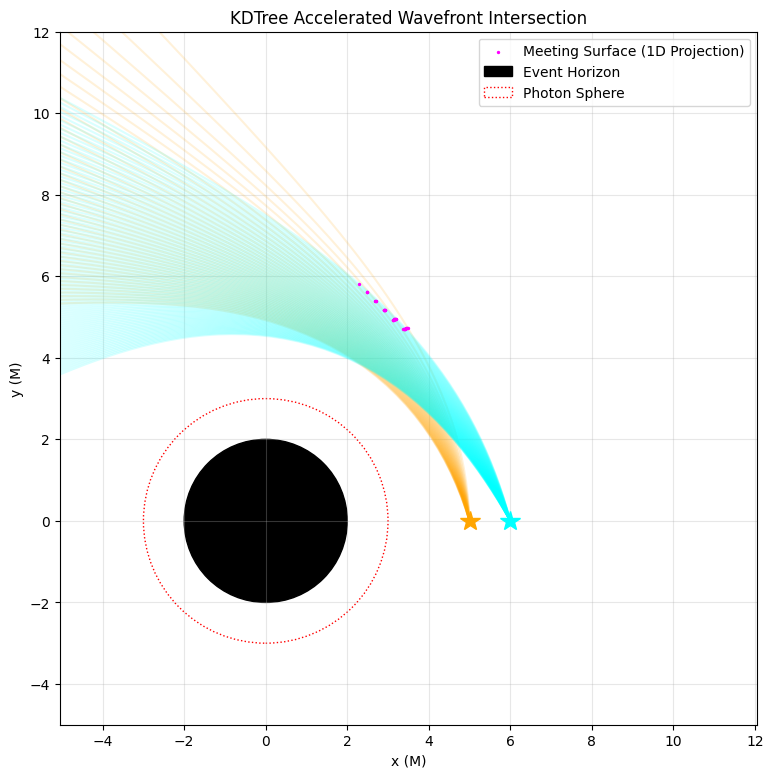

In [18]:
#  Simulation Execution and Plotting
M = 1.0
spacetime = SchwarzschildSpacetime(M)

# 1. Define the parameters
source1 = LightSource(r0=5.0 * M, phi0=0.0, label="Lamp 1 (East)")
source2 = LightSource(r0=6.0 * M, phi0=0.0, label="Lamp 2 (North)")

b_values = np.linspace(6, 7, 1500) * M

# 2. Run the math
data1 = collect_wavefront_data(spacetime, source1, b_values, stride=10)
data2 = collect_wavefront_data(spacetime, source2, b_values, stride=10)
intersections = find_intersections_kdtree(data1, data2, eps_t=0.1, eps_s=0.25)

# 3. Render the output
plt.figure(figsize=(9, 9))

# Plot background rays for visual context
for data, color in [(data1, 'orange'), (data2, 'cyan')]:
    for ray_id in np.unique(data[:, 3])[::15]:  
        mask = data[:, 3] == ray_id
        plt.plot(data[mask, 1], data[mask, 2], color=color, alpha=0.15)
        
# Plot the precise intersection curve
if len(intersections) > 0:
    plt.scatter(
        intersections[:, 0], intersections[:, 1],  
        color='magenta', s=2, zorder=5, label='Meeting Surface (1D Projection)'
    )
    
# Draw environment
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon')
photon_sphere = plt.Circle((0,0), 3*M, color='red', fill=False, linestyle=':', label='Photon Sphere')
plt.gca().add_patch(horizon)
plt.gca().add_patch(photon_sphere)

# Plot Lamps
plt.plot(source1.r0 * np.cos(source1.phi0), source1.r0 * np.sin(source1.phi0), '*', color='orange', markersize=15)
plt.plot(source2.r0 * np.cos(source2.phi0), source2.r0 * np.sin(source2.phi0), '*', color='cyan', markersize=15)

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('KDTree Accelerated Wavefront Intersection')
plt.legend(loc='upper right')
plt.axis('equal')
plt.xlim(-5, 12)
plt.ylim(-5, 12)
plt.grid(True, alpha=0.3)
plt.show()